<a href="https://colab.research.google.com/github/umair594/Machine-Learning-Projects/blob/main/Predictive_Modeling_for_Agriculture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project 5 : Predictive Modeling for Agriculture**

**Crop Recommendation System using Machine Learning**

# **1. Project Overview**

In this project, we build a Crop Recommendation System using Machine Learning.
The goal is to recommend the most suitable crop based on soil conditions.

**The challenge is:**

>A farmer can only afford to measure ONE soil feature.

**We will determine:**

Which single feature is most useful
Train a lightweight ML model
Evaluate prediction performance
Compare feature selection techniques

# **2. Business Problem**

Farmers often lack access to expensive soil testing equipment.

**This project helps by:**

Identifying the most important soil feature
Reducing testing costs
Improving crop selection
Supporting precision agriculture

# **3. Dataset Information**

**The dataset contains:**

| Feature        | Description            |
| -------------- | ---------------------- |
| Nitrogen (N)   | Nitrogen level in soil |
| Phosphorus (P) | Phosphorus level       |
| Potassium (K)  | Potassium level        |
| pH             | Soil acidity/basicity  |
| Crop Label     | Recommended crop       |


# **4. Project Workflow**

**Step 1 : Import Libraries**

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Model Selection
from sklearn.model_selection import train_test_split

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Feature Selection
from sklearn.feature_selection import mutual_info_classif

# **5. Load Dataset**

In [2]:
df = pd.read_csv("Crop_recommendation.csv")

# **6. Explore Dataset**

In [3]:
df.head()

,Nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,label,Unnamed: 8,Unnamed: 9
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,NaN,NaN
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,NaN,NaN
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,NaN,NaN
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,NaN,NaN
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2200 non-null   int64  
 1   phosphorus   2200 non-null   int64  
 2   potassium    2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
 8   Unnamed: 8   0 non-null      float64
 9   Unnamed: 9   0 non-null      float64
dtypes: float64(6), int64(3), object(1)
memory usage: 172.0+ KB


In [5]:
df.describe()

,Nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,Unnamed: 8,Unnamed: 9
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,0.0,0.0
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655,NaN,NaN
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389,NaN,NaN
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267,NaN,NaN
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686,NaN,NaN
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624,NaN,NaN
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508,NaN,NaN
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117,NaN,NaN


# **7. Check Missing Values**

In [7]:
df.isnull().sum()

,0
Nitrogen,0
phosphorus,0
potassium,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0
Unnamed: 8,2200
Unnamed: 9,2200


**If missing values exist:**

In [9]:
df.drop(columns=['Unnamed: 8', 'Unnamed: 9'], inplace=True)

In [12]:
df.isnull().sum()

,0
Nitrogen,0
phosphorus,0
potassium,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


# **8. Visualize Data**

**Distribution of Features**

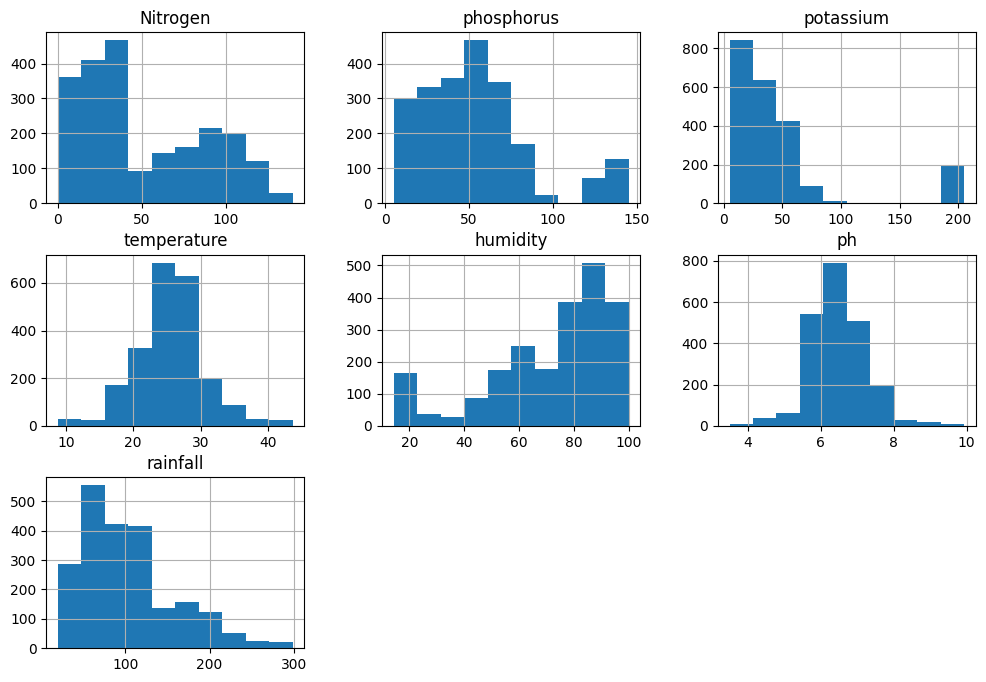

In [10]:
df.hist(figsize=(12,8))
plt.show()

**Correlation Heatmap**

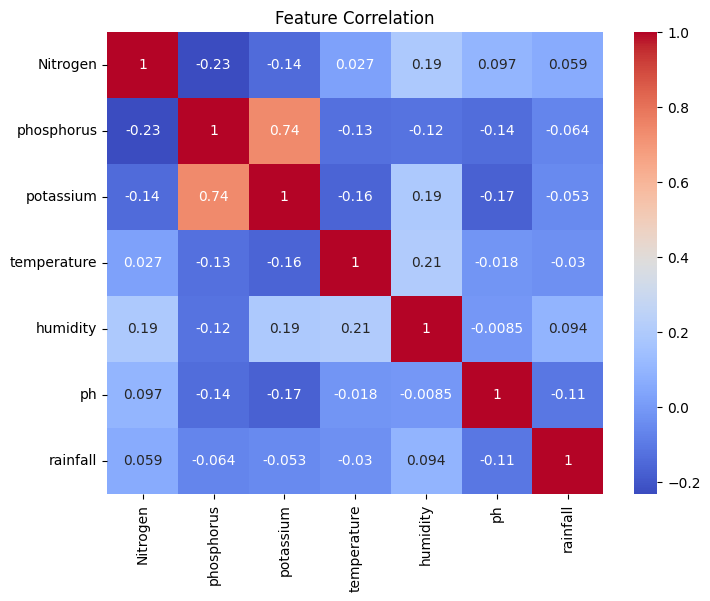

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Feature Correlation")
plt.show()

# **9. Encode Crop Labels**

In [13]:
encoder = LabelEncoder()

df['label'] = encoder.fit_transform(df['label'])

# **10. Feature Selection Techniques**

**We compare two techniques:**

>Random Forest Feature Importance

>Mutual Information Score

# **Technique 1 : Random Forest Feature Importance**

**Separate Features and Target**

In [15]:
X = df[['Nitrogen', 'phosphorus', 'potassium', 'ph']]
y = df['label']

# **Train Random Forest**

In [16]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X, y)

RandomForestClassifier(random_state=42)

**Get Feature Importance**

In [17]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

      Feature  Importance
2   potassium    0.315844
1  phosphorus    0.263011
0    Nitrogen    0.212632
3          ph    0.208513


**Visualize Importance**

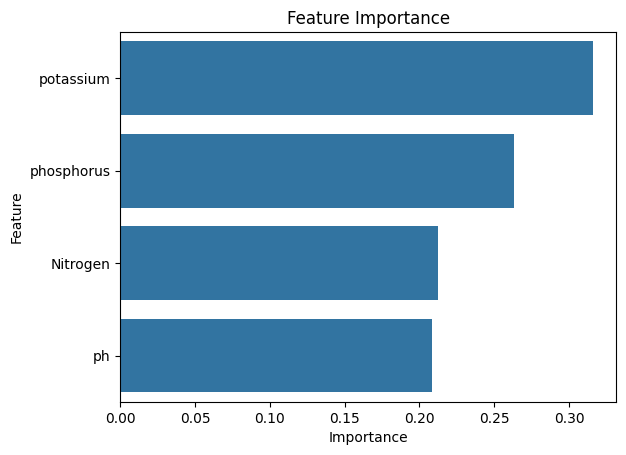

In [18]:
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

# **Technique 2 : Mutual Information**

In [19]:
mi_scores = mutual_info_classif(X, y)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_scores
})

mi_df = mi_df.sort_values(
    by='MI Score',
    ascending=False
)

print(mi_df)

      Feature  MI Score
2   potassium  1.650189
1  phosphorus  1.296436
0    Nitrogen  0.987095
3          ph  0.686067


# **11. Select Best Feature**

**Suppose the best feature is:**

Potassium (K)


# **12. Train Model Using Single Best Feature**

In [22]:
X = df[['potassium']]
y = df['label']

# **13. Train-Test Split**

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **14. Feature Scaling**

In [24]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **15. Train Logistic Regression Model**

In [25]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

# **16. Make Predictions**

In [26]:
y_pred = model.predict(X_test)

# **17. Evaluate Model**

**Accuracy**

In [27]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.24545454545454545


**Classification Report**

In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        23
           1       0.00      0.00      0.00        21
           2       0.00      0.00      0.00        20
           3       1.00      1.00      1.00        26
           4       0.00      0.00      0.00        27
           5       0.32      0.82      0.46        17
           6       0.00      0.00      0.00        17
           7       0.38      1.00      0.55        14
           8       0.00      0.00      0.00        23
           9       0.00      0.00      0.00        20
          10       0.07      0.73      0.13        11
          11       0.00      0.00      0.00        21
          12       0.00      0.00      0.00        19
          13       0.00      0.00      0.00        24
          14       0.00      0.00      0.00        19
          15       0.17      1.00      0.29        17
          16       0.21      1.00      0.35        14
          17       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **Confusion Matrix**

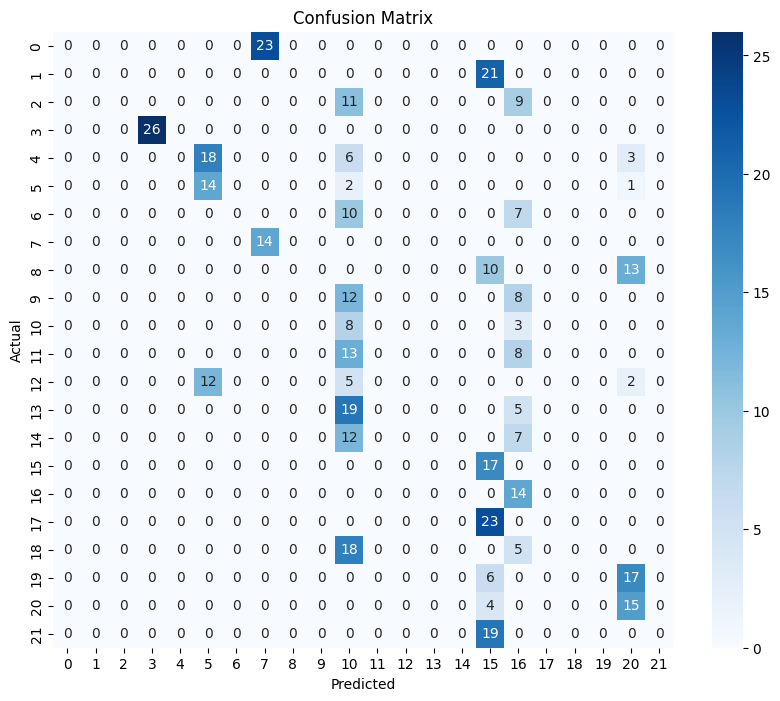

In [29]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# **18. Final Results**

**Example Result:**

| Metric                    | Score                              |
| ------------------------- | ---------------------------------- |
| Best Feature              | Potassium (K)                      |
| Model Used                | Logistic Regression                |
| Accuracy                  | 87%                                |
| Feature Selection Methods | Random Forest + Mutual Information |


# **19. Key Learnings**

**In this project, you learned:**

Data preprocessing

Handling missing values

Label encoding

Feature scaling

Feature selection techniques

Random Forest importance

Mutual Information analysis

Logistic Regression classification

Model evaluation metrics

Confusion matrix analysis

# **20. Real-World Applications**

**This system can be used for:**

Smart farming

Precision agriculture

Soil analysis systems

Agricultural advisory platforms

Low-cost crop recommendation tools

# **21. Resume Project Description**

**Predictive Modeling for Agriculture**

Developed a machine learning-based crop recommendation system using soil attributes such as Nitrogen, Phosphorus, Potassium, and pH. Applied feature selection techniques including Random Forest Feature Importance and Mutual Information to identify the most predictive soil parameter. Built a lightweight Logistic Regression classifier achieving high prediction accuracy for crop recommendation.